# Build and plot radiometric spectral response curves

Paul Montesano, PhD  
Sept 2026

In [2]:
library(tidyverse)
library(patchwork)
library(RColorBrewer)
library(dplyr)

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────

In [3]:
#MAINDIR = '/explore/nobackup/projects/CSDA_eval/results/maxar/legion/geometric'

band_colors <- c(
  'Pan' = 'gray',
  'Coastal'  = '#4f3a89', 'Blue'     = '#1f78b4',
  'Green'    = '#33a02c', 'Green1'    = '#33a02c',
    'Yellow'   = '#ffd92f',
  'Red'      = '#e31a1c', 
  'RedEdge' = '#b15928',
  'RedEdge1' = '#b15928',
  'RedEdge2' = '#b15928', #'#8b3a00', 
    'NIR' = 'indianred','NIR1'= 'indianred','NIR2'= 'indianred', #'#525252'
    'Cirrus'='steelblue','SWIR1'='steelblue','SWIR2'='steelblue',
    'Swir1'='steelblue','Swir2'='steelblue','Swir3'='steelblue','Swir4'='steelblue','Swir5'='steelblue','Swir6'='steelblue','Swir7'='steelblue','Swir8'='steelblue',
    'TIR1'='#B63679FF','TIR2'='#B63679FF'
)

band_order <- c('Pan','Coastal', 'Blue', 'Green', 'Green1', 'Yellow', 'Red',
                'RedEdge','RedEdge1', 'RedEdge2', 'NIR','NIR1','NIR2','Cirrus','SWIR1','SWIR2','Swir1','Swir2','Swir3','Swir4','Swir5','Swir6','Swir7','Swir8','TIR1','TIR2'
)


sat_colors <- c(
  'LG01' = '#1b9e77', 'LG02' = '#d95f02', 'LG03' = '#7570b3',
  'LG04' = '#e7298a', 'LG05' = '#66a61e', 'LG06' = '#e6ab02',
  'LG07' = '#a6761d', 'LG08' = '#666666', 'LG09' = '#1f78b4'
)

In [4]:
# options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)

# library(viridisLite)
# library(scales)

# # Generate and display 12 colors from the magma palette
# show_col(magma(5))
# magma(5)

In [27]:
# Define the root search path
DIR_EVAL_RESULTS_DB="/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db"
DIR_RSR_RESULTS <- paste0(DIR_EVAL_RESULTS_DB, "/rsr")
CSDA_RSR_CURVE_DATA_FN = paste0(results_path,'/','csda_rsr_curve_data.csv') 

### RSR Curves

### Load a variety of RSR files

In [28]:
rsr_files = list.files(
    path = results_path,
    pattern = "RSR.*\\.csv$",
    recursive = TRUE,
    full.names = TRUE
)

df_rsr <- rsr_files %>%
  set_names() %>%
  #map_df(read_csv, .id = "source_file") %>%
  map_df(read_csv, show_col_types = FALSE, .id = "source_file")  %>%
  mutate(
    affiliation = case_when(
      str_detect(sensor, "^LG0")    ~ "Vantor",
      str_detect(sensor, "^newsat") ~ "Satellogic",
      str_detect(sensor, "^PHR1|^PNEO|^SPOT") ~ "Airbus",
      str_detect(sensor, "^BS")     ~ "BlackSky",
      .default = NA_character_
    ),
    constellation = case_when(
      str_detect(sensor, "^LG0")    ~ "Legion",
      str_detect(sensor, "^newsat") ~ "Aleph-1",
      str_detect(sensor, "^PHR1")   ~ "Pleiades",
      str_detect(sensor, "^PNEO")   ~ "PleiadesNeo",
      str_detect(sensor, "^SPOT")   ~ "SPOT",
      str_detect(sensor, "^BS")     ~ "Global",
      .default = NA_character_
    ),
    band = as.character(band),
    band = case_when(
      str_detect(band, "Coastal")   ~ "Coastal",
      str_detect(band, "Red_Edge")  ~ "RedEdge",
      .default = band
    ),
    band   = factor(band, levels = band_order),
    sensor = factor(sensor)
  ) %>%
  select(-source_file, everything(), source_file) %>%
  droplevels()
dim(df_rsr)

[1] 32481     7

### Load and integrate MAXAR legacy RSR Data

The MAXAR legacy RSR files have different headers and wavelength units in nm. The code below reads them all.

In [29]:
read_maxar_legacy_rsr <- function(file_path) {
  
  # ── Read raw lines to extract band names from header ─────────────────────────
  lines     <- readLines(file_path, warn = FALSE)
  
  # ── Row 1: band names (split on whitespace, drop first element "BAND") ───────
  band_names <- str_split(lines[1], "\\s+")[[1]] %>%
    str_trim() %>%
    .[. != ""] %>%   # drop any empty strings from leading whitespace
    .[-1]            # drop "BAND" / "WL" label
  
  # ── Read data rows (skip header row 1) ───────────────────────────────────────
  df <- read_table(
    file_path,
    skip           = 1,
    col_names      = c("wavelength_nm", band_names),
    col_types      = cols(.default = col_double()),
    show_col_types = FALSE
  )
  
  # ── Convert wavelength if needed (micrometers → nanometers) ──────────────────
  if (min(df$wavelength_nm, na.rm = TRUE) < 50) {
    df <- df %>% mutate(wavelength_nm = wavelength_nm * 1000)
  }
  
  # ── Pivot to long format ──────────────────────────────────────────────────────
  df <- df %>%
    pivot_longer(
      cols           = -wavelength_nm,
      names_to       = "band",
      values_to      = "rsr",
      values_drop_na = FALSE
    ) %>%
    # ── Standardize band names ──────────────────────────────────────────────────
    mutate(
      band = str_trim(band),
      band = case_when(
        str_detect(band, "(?i)^pan$")                     ~ "Pan",
        str_detect(band, "(?i)coastal")                   ~ "Coastal",
        str_detect(band, "(?i)^blue$")                    ~ "Blue",
        str_detect(band, "(?i)^green$")                   ~ "Green",
        str_detect(band, "(?i)^yellow$")                  ~ "Yellow",
        str_detect(band, "(?i)rededge|red.edge|red-edge") ~ "RedEdge",
        str_detect(band, "(?i)^red$")                     ~ "Red",
        str_detect(band, "(?i)nir1")                      ~ "NIR1",
        str_detect(band, "(?i)nir2")                      ~ "NIR2",
        str_detect(band, "(?i)^nir$")                     ~ "NIR",
        TRUE ~ str_to_title(band)
      )
    )
  
  # ── Extract sensor name from filename ─────────────────────────────────────────
  # e.g. "BandPass_WorldView-2_RSR.txt" -> "WorldView-2"
  filename   <- basename(file_path)
  sensor_raw <- str_extract(filename, "(?<=BandPass_).+?(?=_RSR|_rsr|\\.txt$)") %>%
    str_trim()
  if (is.na(sensor_raw)) sensor_raw <- str_remove(filename, "\\.txt$")
  
  # ── Infer constellation ───────────────────────────────────────────────────────
  constellation <- case_when(
    str_detect(sensor_raw, "(?i)worldview")  ~ "WorldView",
    str_detect(sensor_raw, "(?i)geoeye")     ~ "GeoEye",
    str_detect(sensor_raw, "(?i)quickbird")  ~ "QuickBird",
    str_detect(sensor_raw, "(?i)ikonos")     ~ "IKONOS",
    TRUE ~ sensor_raw
  )
  
  df <- df %>%
    mutate(
      sensor        = sensor_raw,
      affiliation   = "Maxar",
      constellation = constellation
    )
  
  return(df)
}

In [30]:
# Read all MAXAR legacy RSR files
maxar_dir <- "/home/pmontesa/CSDA_eval/results/maxar"
maxar_legacy_files <- list.files(
  path       = maxar_dir,
  pattern    = "^BandPass.*\\.txt$",
  recursive  = TRUE,
  full.names = TRUE
)

df_rsr_maxar_legacy <- maxar_legacy_files %>%
  set_names() %>%
  map_df(read_maxar_legacy_rsr, .id = "source_file")
dim(df_rsr_maxar_legacy)

[1] 47836     7

### Load and integrate Planet RSR Data

The Planet RSR files have different header names and wavelength units. The code below reads them all, normalizes the columns, and combines with the existing df_rsr dataframe.

In [31]:
# Helper function to read and normalize Planet RSR files
read_planet_rsr <- function(file_path) {
  # Read the file
  df <- read_csv(file_path, show_col_types = FALSE)
  
  # Get the filename for sensor extraction
  filename <- basename(file_path)
  
  # Standardize column names - rename first column to wavelength
  df <- df %>%
    rename_with(~"wavelength", 1) %>%
    rename_all(tolower)
  
  # Convert wavelength to nm if needed
  # If wavelengths are small (< 50), assume micrometers; if >= 200, assume nanometers
  if (min(df$wavelength, na.rm = TRUE) < 50) {
    df <- df %>% mutate(wavelength = wavelength * 1000)
  }
  df <- df %>% rename(wavelength_nm = wavelength)
  
  # Pivot to long format, keeping wavelength_nm and pivoting spectral bands
  df <- df %>%
    pivot_longer(
      cols = -wavelength_nm,
      names_to = "band",
      values_to = "rsr",
      values_drop_na = FALSE
    ) %>%
    # Clean up band names - remove extra text and spaces
    mutate(
      band = str_trim(band),
      band = str_replace_all(band, "_i i", ""),
      band = str_replace_all(band, "_i$", ""),
      band = str_replace_all(band, " response$", ""),
      band = str_replace_all(band, "-blue", ""),
      band = case_when(
        str_detect(band, "blue") ~ "Blue",
          str_detect(band, "coastal") ~ "Coastal",
        str_detect(band, "green_i") ~ "Green",
          str_detect(band, "green_ii") ~ "Green1",
        str_detect(band, "yellow") ~ "Yellow",
        str_detect(band, "red edge|red-edge") ~ "RedEdge",
        str_detect(band, "^red$") ~ "Red",
        str_detect(band, "nir|near") ~ "NIR",
        str_detect(band, "^pan$") ~ "Pan",
        TRUE ~ str_to_title(band)
      )
    )
  
  # Extract sensor and constellation from filename
  sensor_info <- case_when(
    str_detect(filename, "dove_r|Dove") ~ list(sensor = "Dove-R", constellation = "Dove-R"),
    str_detect(filename, "PlanetScope|planetscope") ~ {
      sat_id <- str_extract(filename, "(?<=SatID_)[0-9a-fA-F]+")
      if (is.na(sat_id)) sat_id <- "PlanetScope"
      list(sensor = paste0("PlanetScope_", sat_id), constellation = "Dove-Classic")
    },
    str_detect(filename, "RapidEye") ~ list(sensor = "RapidEye", constellation = "RapidEye"),
      str_detect(filename, "Skysat|SkySat") ~ {
          # Extract all numbers that follow any "skysat" string (case-insensitive)
          nums <- str_extract_all(filename, "(?i)(?<=skysat)\\d+")[[1]]
          
          if (length(nums) >= 2) {
            sensor_name <- paste0("SkySat ", nums[1], "-", nums[2])  # e.g. "SkySat 14-19"
          } else if (length(nums) == 1) {
            sensor_name <- paste0("SkySat ", nums[1])                 # e.g. "SkySat 4"
          } else {
            sensor_name <- "SkySat"                                   # fallback
          }
          list(sensor = sensor_name, constellation = "SkySat")
        },
    str_detect(filename, "Superdove") ~ list(sensor = "SuperDove", constellation = "SuperDove"),
    TRUE ~ list(sensor = str_remove(filename, "\\.csv$"), constellation = "Planet")
  )
  
  df <- df %>%
    mutate(
      sensor = sensor_info$sensor,
      affiliation = "Planet",
      constellation = sensor_info$constellation
    )
  
  return(df)
}

In [32]:
# Read all Planet RSR files
planet_dir <- "/home/pmontesa/CSDA_eval/results/planet"
planet_files <- list.files(planet_dir, pattern = "\\.csv$", full.names = TRUE)

# Use safely to handle any files that might fail to read
df_planet_rsr <- planet_files %>%
  set_names() %>%
  map_df(safely(read_planet_rsr), .id = "source_file") %>%
  #filter(!is.na(result)) %>%
  unnest(result) %>%
  #select(-error) %>%
  mutate(sensor = factor(sensor)) %>%
  droplevels()
dim(df_planet_rsr)

[1] 58310     7

### Load Landsat and Sentinetl RSRs

In [33]:
# Read all civil RSR files
civil_dir <- paste0(DIR_EVAL_RESULTS_DB, "/rsr/civil")
civil_files <- list.files(civil_dir, pattern = "\\.csv$", full.names = TRUE)

# Use safely to handle any files that might fail to read
df_rsr_civil <- civil_files %>%
  set_names() %>%
  map_df(read_csv, .id = "source_file", show_col_types = FALSE) %>%
  mutate(sensor = factor(sensor)) %>%
  select(-source_file, everything(), source_file) %>%
  droplevels()
dim(df_rsr_civil)

[1] 32481     7

In [34]:
head(df_rsr_civil)

wavelength_nm,rsr,band,sensor,affiliation,constellation,source_file
<dbl>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>
427,0.00036798,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
428,0.00072189,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
429,0.00205797,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
430,0.00360595,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
431,0.00877048,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
432,0.02224460,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv


### Combine all RSR data frames

In [36]:
colnames(df_rsr_commercial)

[1] "source_file"   "wavelength_nm" "band"          "rsr"          
[5] "sensor"        "affiliation"   "constellation" "sector"

In [37]:
colnames(df_rsr_civil)

[1] "wavelength_nm" "rsr"           "band"          "sensor"       
[5] "affiliation"   "constellation" "source_file"   "sector"

In [42]:
# Combine with existing df_rsr
df_rsr_commercial <- bind_rows(
    df_rsr_maxar_legacy %>%
    mutate(
      band = as.character(band),
      sensor = as.character(sensor)
    ),
  df_rsr %>%
    mutate(
      band = as.character(band),
      sensor = as.character(sensor)
    ),
  df_planet_rsr %>%
    select(wavelength_nm, rsr, sensor, band, affiliation, constellation, source_file)
 ) %>%
 mutate(sector = 'Commercial')

 df_rsr_civil = df_rsr_civil %>%
    mutate(
      band = as.character(band),
      sensor = as.character(sensor),
      sector = 'Civil'  
    )

df_rsr_combined = bind_rows(df_rsr_commercial, df_rsr_civil) %>%
  mutate(
    # Standardize band names across all sources
    band = case_when(
      str_detect(band, 'Coastal|Coastal-Blue') ~ 'Coastal',
      #   str_detect(band, 'Green') ~ 'Green',
      # str_detect(band, 'Red.?[Ee]dge|RedEdge') ~ 'RedEdge',
      #   str_detect(band, 'NIR') ~ 'NIR',
      #   str_detect(band, 'SWIR') ~ 'SWIR',
      TRUE ~ band
    ),
    band = factor(band, levels = band_order),
    sensor = factor(sensor)
  ) %>%
  select(-source_file, everything(), source_file) %>%
  #select(!c('Wavelength [µm]','Blue','Green','Red','NIR','WL [µm]','Wavelength [um]','Red Edge','Pan')) %>% 
  droplevels() %>% drop_na()


#cat("Loaded", nrow(df_planet_rsr), "rows from", length(planet_files), "Planet RSR files\n")
cat("Total rows in combined df_rsr:", nrow(df_rsr_combined), "\n")

# Diagnostic: Check what's in df_rsr after combining
cat("Unique affiliations in df_rsr:\n")
print(table(df_rsr_combined$affiliation))
cat("\n")
cat("Unique constellations in df_rsr:\n")
print(table(df_rsr_combined$constellation))
cat("\n")

Total rows in combined df_rsr: 134025 
Unique affiliations in df_rsr:

      ESA     Maxar NASA/USGS    Planet 
    25311     47836      2568     58310 

Unique constellations in df_rsr:

Dove-Classic       Dove-R       GeoEye      Landsat    QuickBird     RapidEye 
         788         2404         3755         2568          755         5005 
    Sentinel       SkySat    SuperDove          WV2          WV3 
       25311        45305         4808         6759        36567 



In [44]:
tail(df_rsr_combined)

wavelength_nm,band,rsr,sensor,affiliation,constellation,sector,source_file
<dbl>,<fct>,<dbl>,<fct>,<chr>,<chr>,<chr>,<chr>
2595,SWIR2,0,MSI 2C,ESA,Sentinel,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2596,SWIR2,0,MSI 2C,ESA,Sentinel,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2597,SWIR2,0,MSI 2C,ESA,Sentinel,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2598,SWIR2,0,MSI 2C,ESA,Sentinel,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2599,SWIR2,0,MSI 2C,ESA,Sentinel,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2600,SWIR2,0,MSI 2C,ESA,Sentinel,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv


## Write RSR dB

In [39]:
write_csv(df_rsr_combined, CSDA_RSR_CURVE_DATA_FN)

In [40]:
dim(df_rsr_combined %>% filter(sensor == 'SuperDove') %>% filter(band == 'Green'))

[1] 1202    8

In [17]:
dim(df_rsr_combined %>% filter(sensor == 'SuperDove') %>% filter(band != 'Green'))

[1] 3606    8

## Plot RSR dB

In [45]:
# PLOT_RSR_CURVES <- function(df_rsr_combined){
#     # 2. Build the ggplot visualization with filled areas
#     rsr_plot <- ggplot(df_rsr_combined %>% drop_na() %>% filter(rsr != 0), aes(x = wavelength_nm, y = rsr, color = band, fill = band, group = interaction(sensor, band))) +
#       # NEW: Add filled area layer under the lines
#       # position = "identity" prevents the bands from stacking on top of each other
#       geom_area(position = "identity", alpha = 0.1, color = NA) + 
      
#       # Keep the clear outer boundary lines on top
#       geom_line(linewidth = 0.2, alpha = 0.9) +
#       coord_cartesian(ylim = c(0.25,1)) +
      
#       #facet_wrap(~sensor, ncol = 2, scales = "free_y") +
      
#       # Map your explicit hex color vector to BOTH line colors and area fills
#       scale_color_manual(values = band_colors, name = "Spectral Band") +
#       scale_fill_manual(values = band_colors, name = "Spectral Band") +
      
#       labs(
#         title = "Spaceborne Optical Image Relative Spectral Response Curves" ,
#         #subtitle = "Vantor Legion Satellites (LG01–LG06)",
#         x = "Wavelength (nm)",
#         y = "Relative Spectral Response"
#       ) +
#       theme_bw(base_size = 11) +
#       theme(
#         strip.text.y = element_text(face = "bold", size = 6,angle = 0),
#         panel.grid.minor = element_blank(),
#         legend.position = "right",
#         legend.title = element_text(face = "bold"),
#         plot.title = element_text(face = "bold", size = 13)
#       ) +
#       facet_grid(sector+affiliation+constellation~.) +
#       guides(
#             fill = guide_legend(override.aes = list(alpha = 1))
#         )
    
#     print(rsr_plot)
#     }

In [19]:
PLOT_RSR_CURVES <- function(df_rsr_combined) {
  
  # ── Collapsed legend label lookup ─────────────────────────────────────────────
  collapse_band <- function(b) {
    case_when(
      str_detect(b, "(?i)swir")    ~ "SWIR",
      str_detect(b, "(?i)rededge") ~ "RedEdge",
      str_detect(b, "(?i)^nir")    ~ "NIR",
      str_detect(b, "(?i)^tir")    ~ "TIR",
      TRUE                         ~ b
    )
  }
  
  # ── Derive legend_band levels from band_order (collapse groups, keep order) ───
  legend_band_levels <- band_order %>%
    collapse_band() %>%
    unique()   # preserves order of first appearance in band_order
  
  # ── Create plot data - original data untouched ────────────────────────────────
  plot_data <- df_rsr_combined %>%
    drop_na() %>%
    filter(rsr != 0) %>%
    mutate(
      legend_band = factor(
        collapse_band(as.character(band)),
        levels = legend_band_levels
      )
    )
  
  # ── Helper to grab first matching color from band_colors ─────────────────────
  first_match_col <- function(pattern) {
    unname(band_colors[str_detect(names(band_colors), pattern)][1])
  }
  
  # ── Build legend color vector - drop sub-bands, add one entry per group ───────
  legend_band_colors <- c(
    band_colors[!str_detect(names(band_colors), "(?i)swir|rededge|^nir|^tir")],
    "NIR"     = first_match_col("(?i)^nir"),
    "RedEdge" = first_match_col("(?i)rededge"),
    "SWIR"    = first_match_col("(?i)swir"),
    "TIR"     = first_match_col("(?i)^tir")
  )
  
  # ── Plot ──────────────────────────────────────────────────────────────────────
  rsr_plot <- ggplot(
    plot_data,
    aes(
      x     = wavelength_nm,
      y     = rsr,
      color = legend_band,
      fill  = legend_band,
      group = interaction(sensor, band)   # keeps all sub-bands plotted separately
    )
  ) +
    geom_area(position = "identity", alpha = 0.1, color = NA) +
    geom_line(linewidth = 0.2, alpha = 0.9) +
    coord_cartesian(ylim = c(0.25, 1)) +
    scale_color_manual(values = legend_band_colors, name = "Spectral Band") +
    scale_fill_manual(values  = legend_band_colors, name = "Spectral Band") +
    labs(
      title = "Spaceborne Optical Image Relative Spectral Response Curves",
      x     = "Wavelength (nm)",
      y     = "Relative Spectral Response"
    ) +
    theme_bw(base_size = 11) +
    theme(
      strip.text.y     = element_text(face = "bold", size = 6, angle = -90),
      panel.grid.minor = element_blank(),
      legend.position  = "right",
      legend.title     = element_text(face = "bold"),
      plot.title       = element_text(face = "bold", size = 13)
    ) +
    facet_grid(sector + affiliation + constellation ~ .) +
    guides(fill = guide_legend(override.aes = list(alpha = 1)))
  
  print(rsr_plot)
}

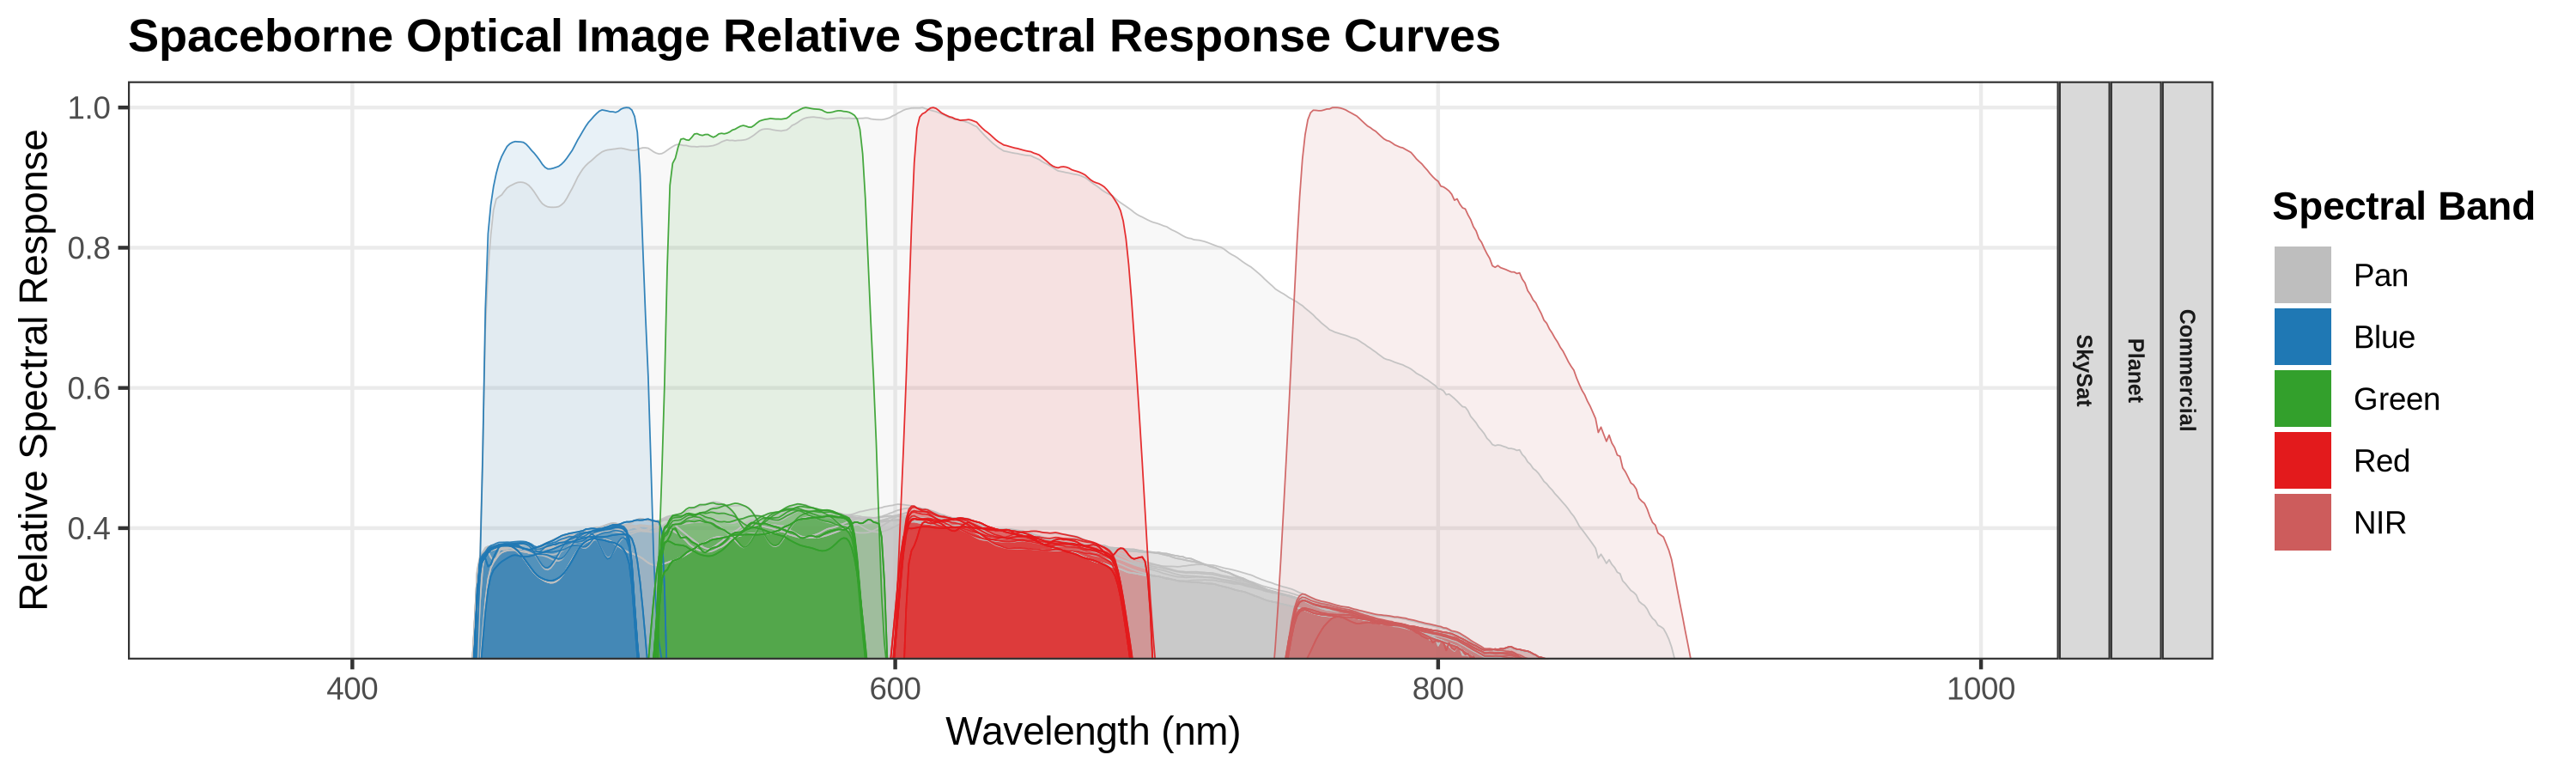

In [20]:
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(constellation == 'SkySat'))

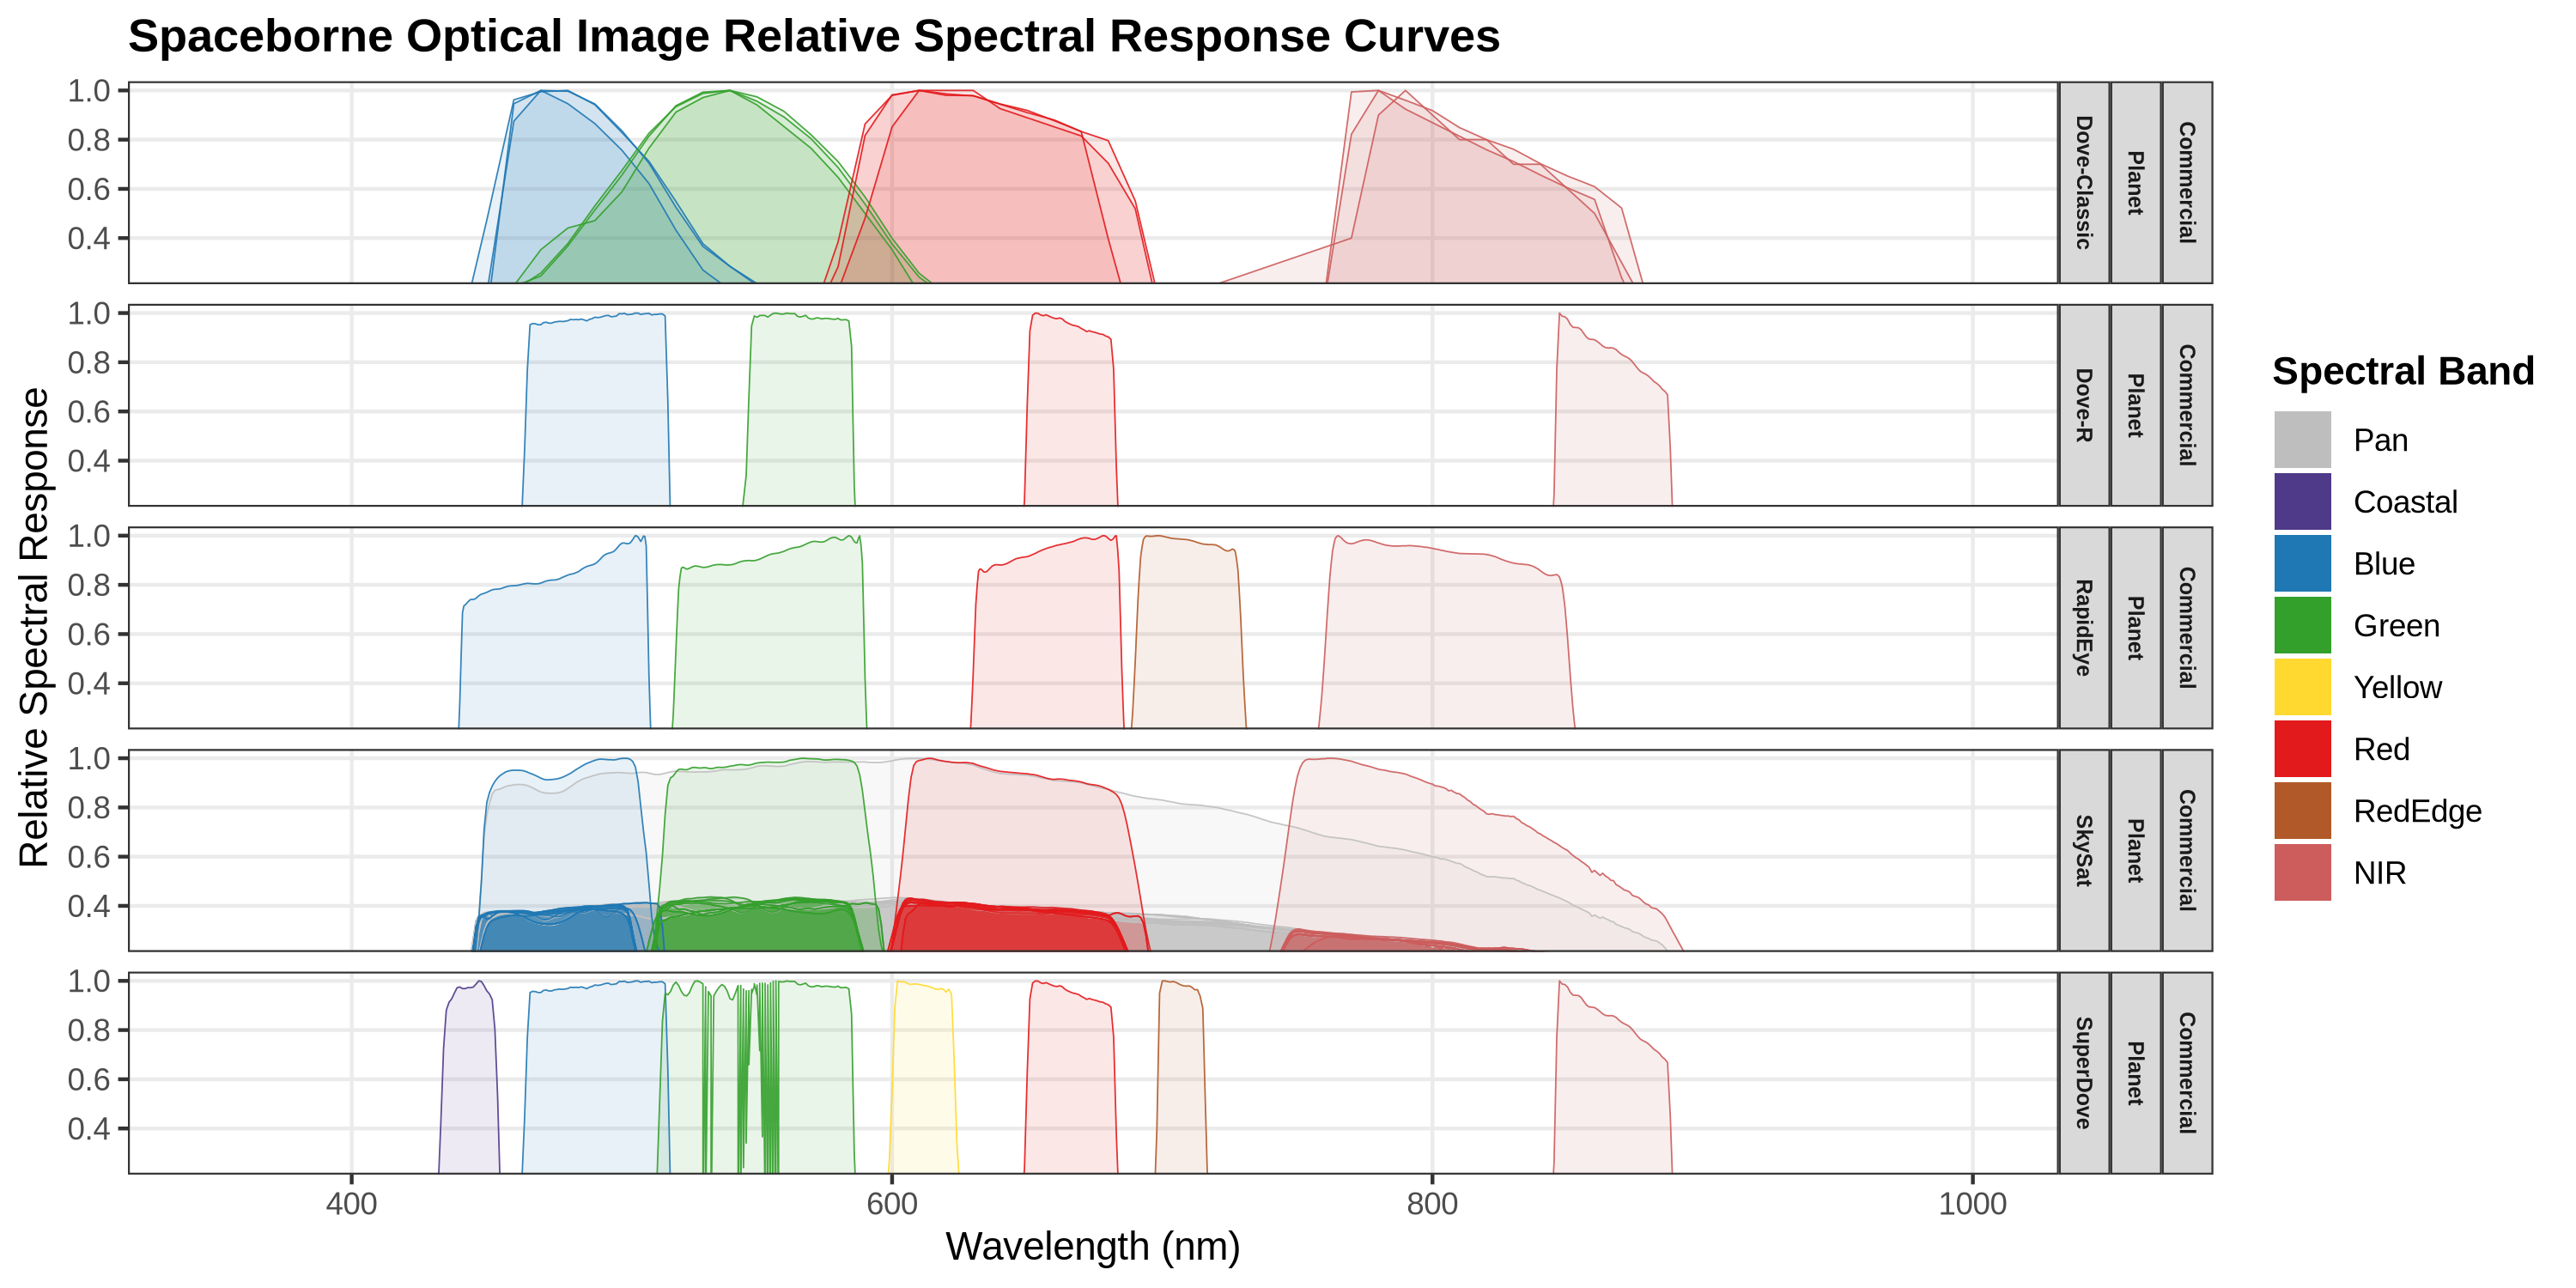

In [46]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(affiliation == 'Planet'))

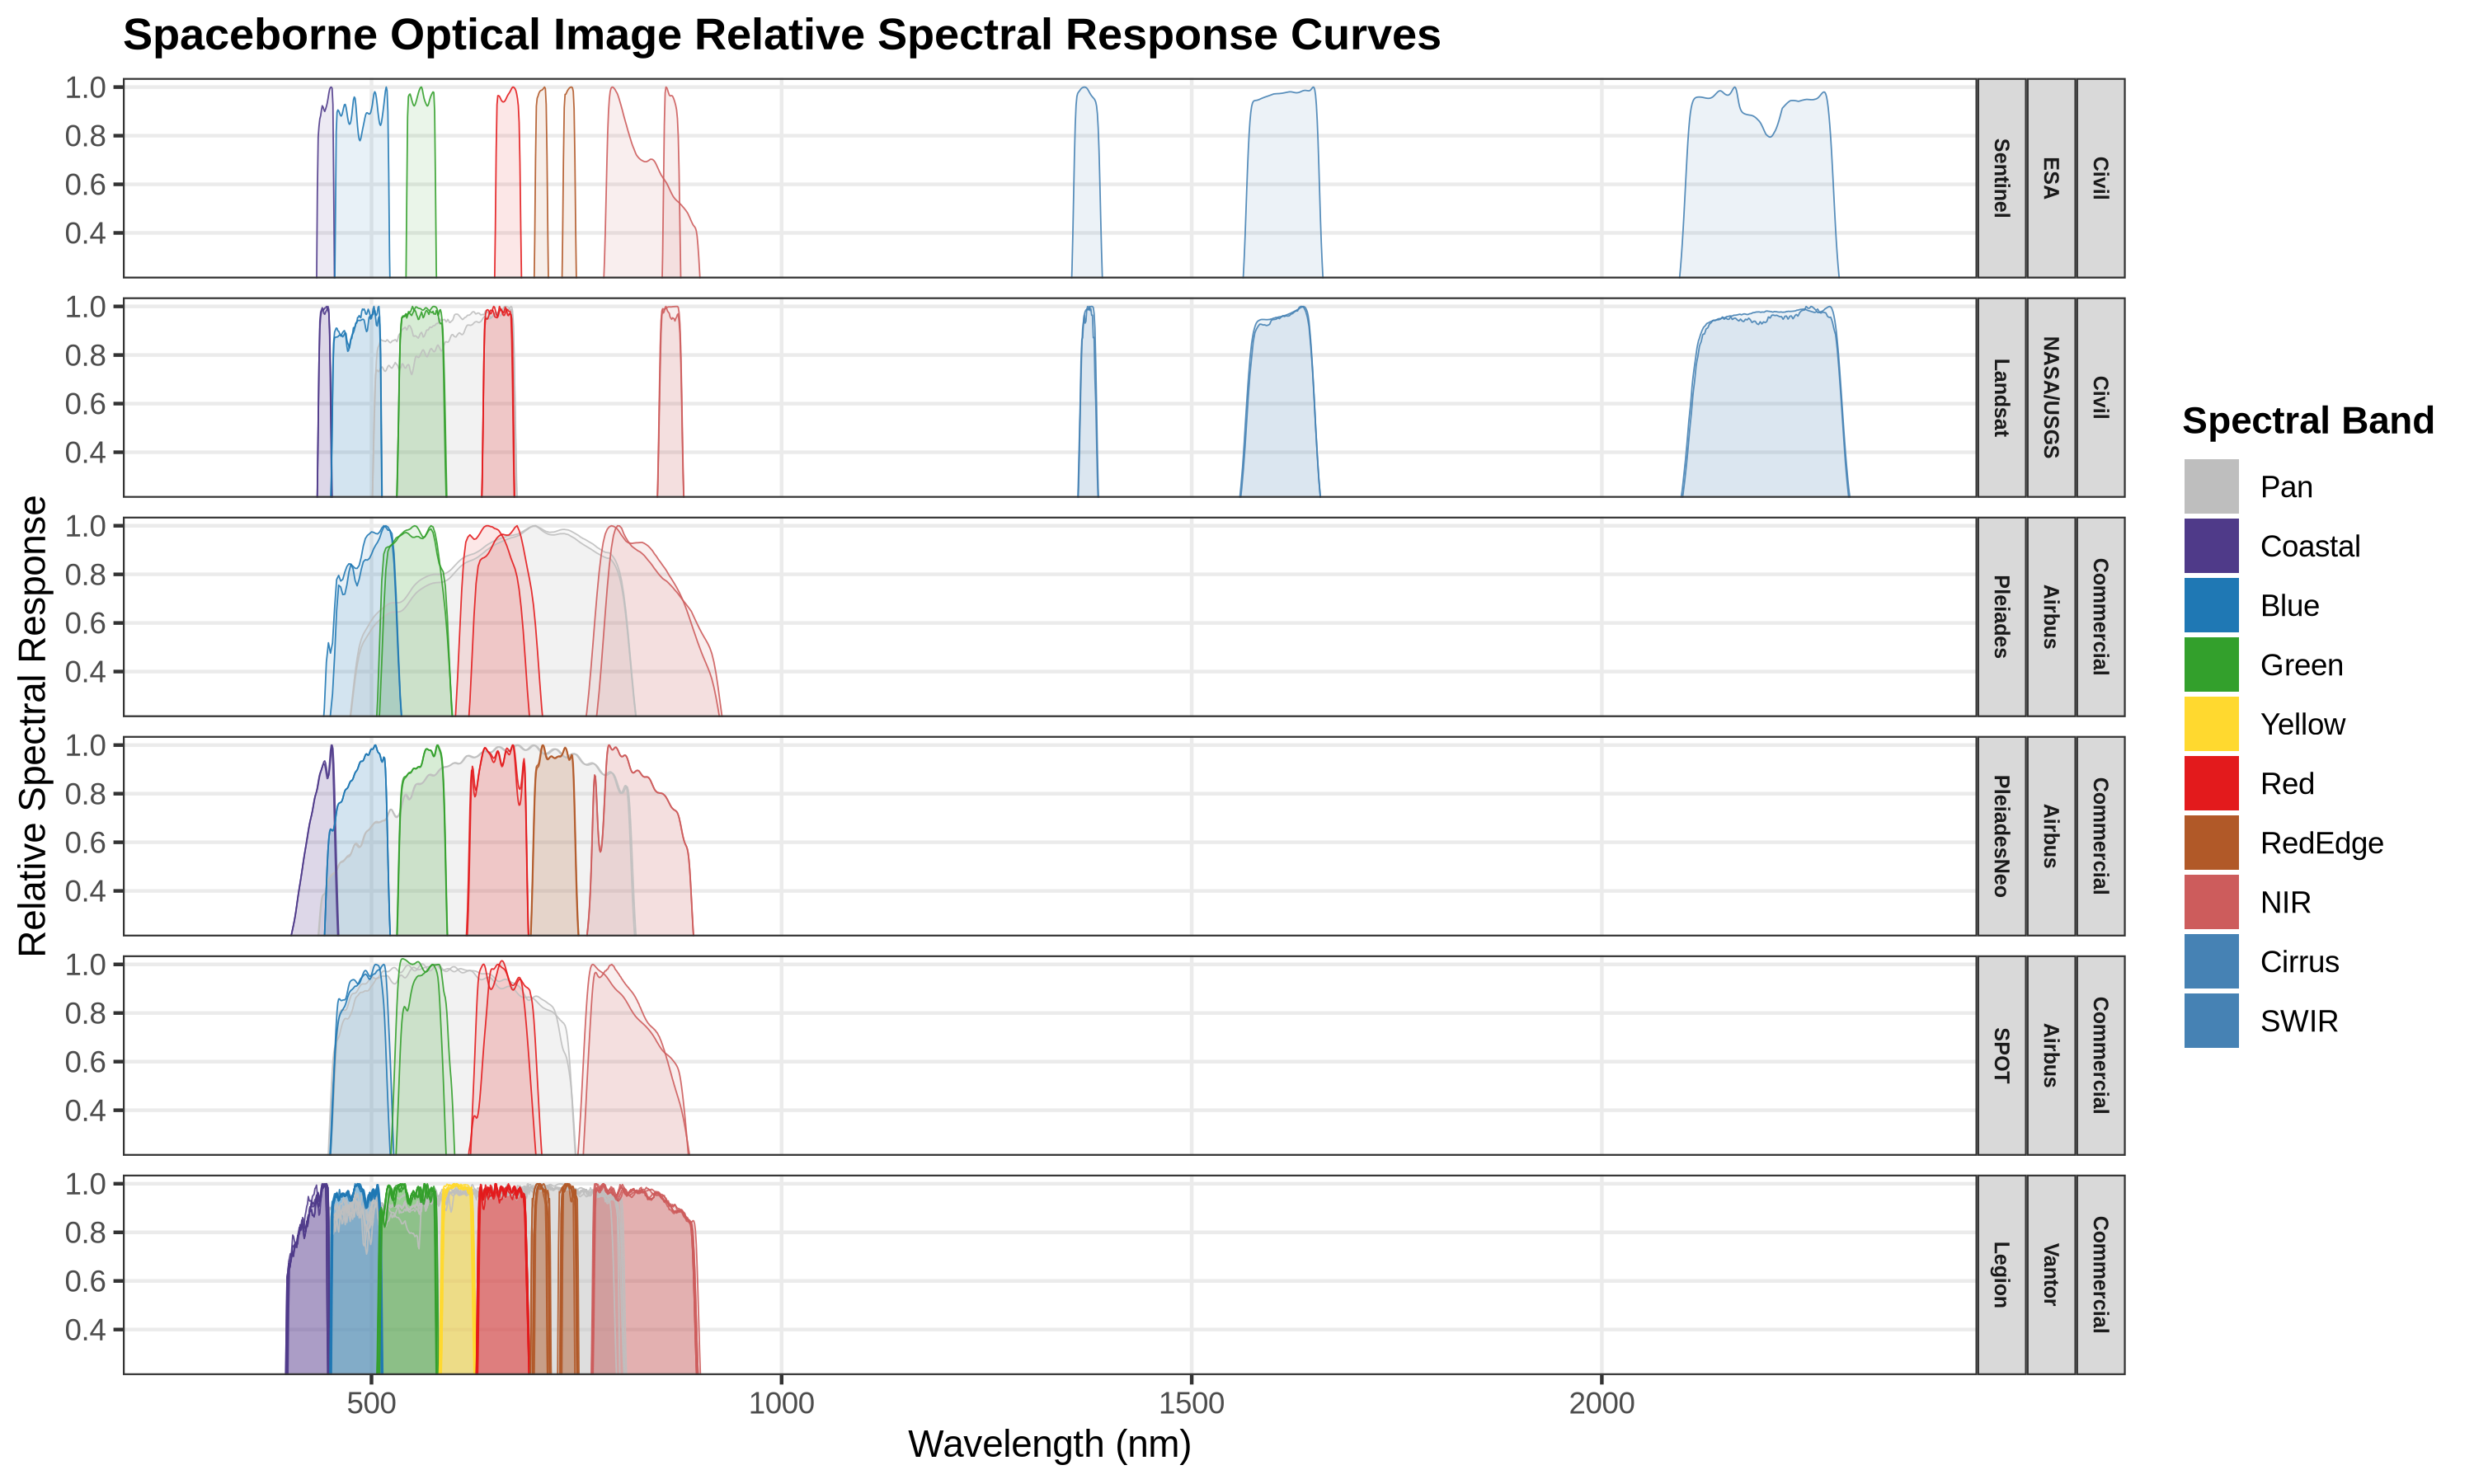

In [23]:
options(repr.plot.width = 10, repr.plot.height = 6, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(constellation %in% c("Pleiades","PleiadesNeo","SPOT", "Legion", "Sentinel", "Landsat")) %>% filter(!(band %in% c('TIR1','TIR2'))))

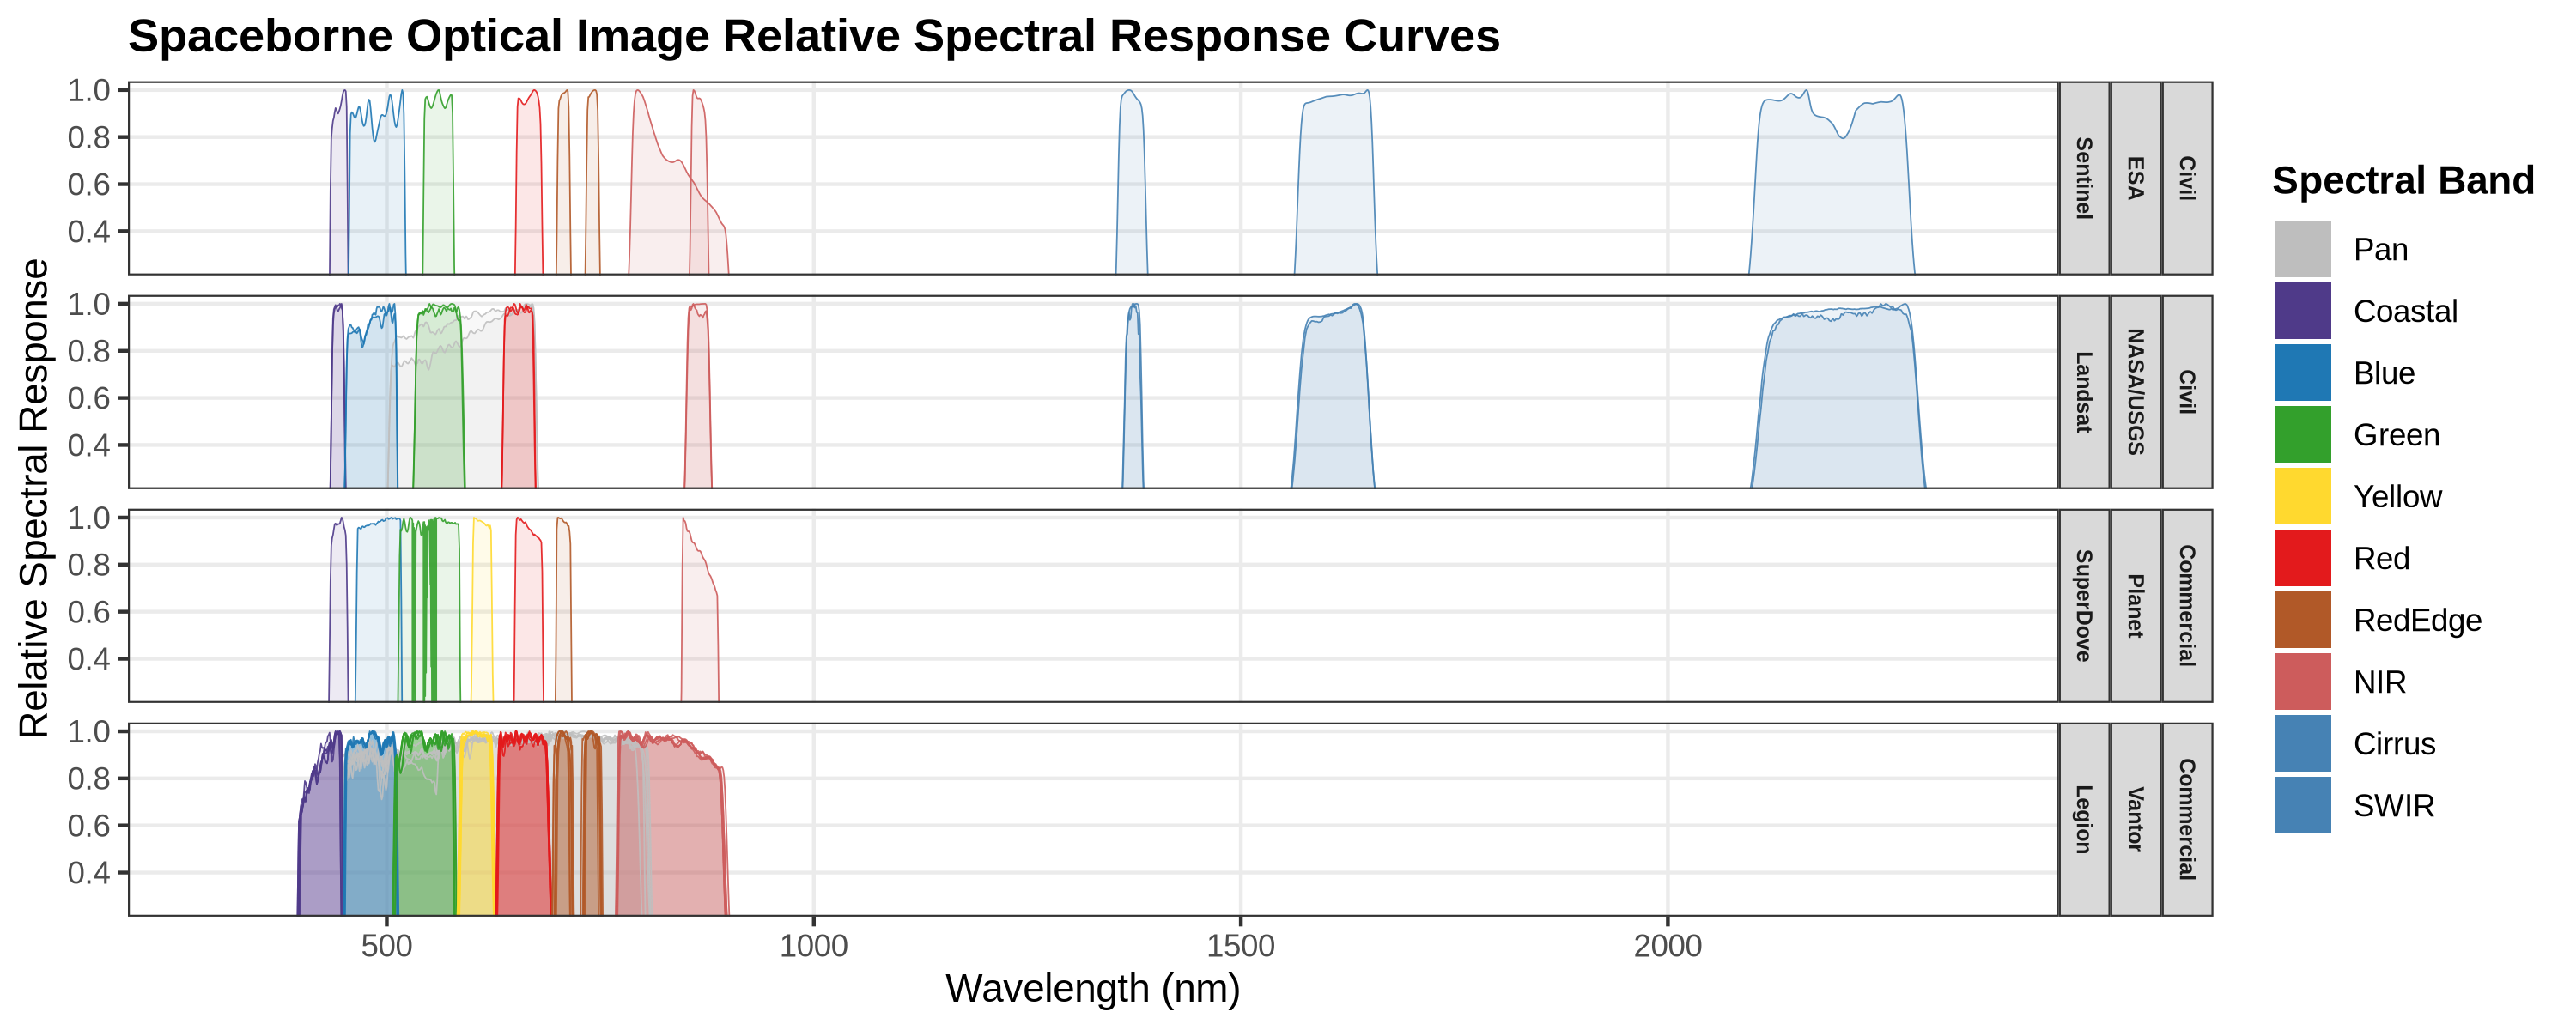

In [20]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(constellation %in% c("Legion", "SuperDove", "Sentinel", "Landsat")) %>% filter(!(band %in% c('TIR1','TIR2'))))

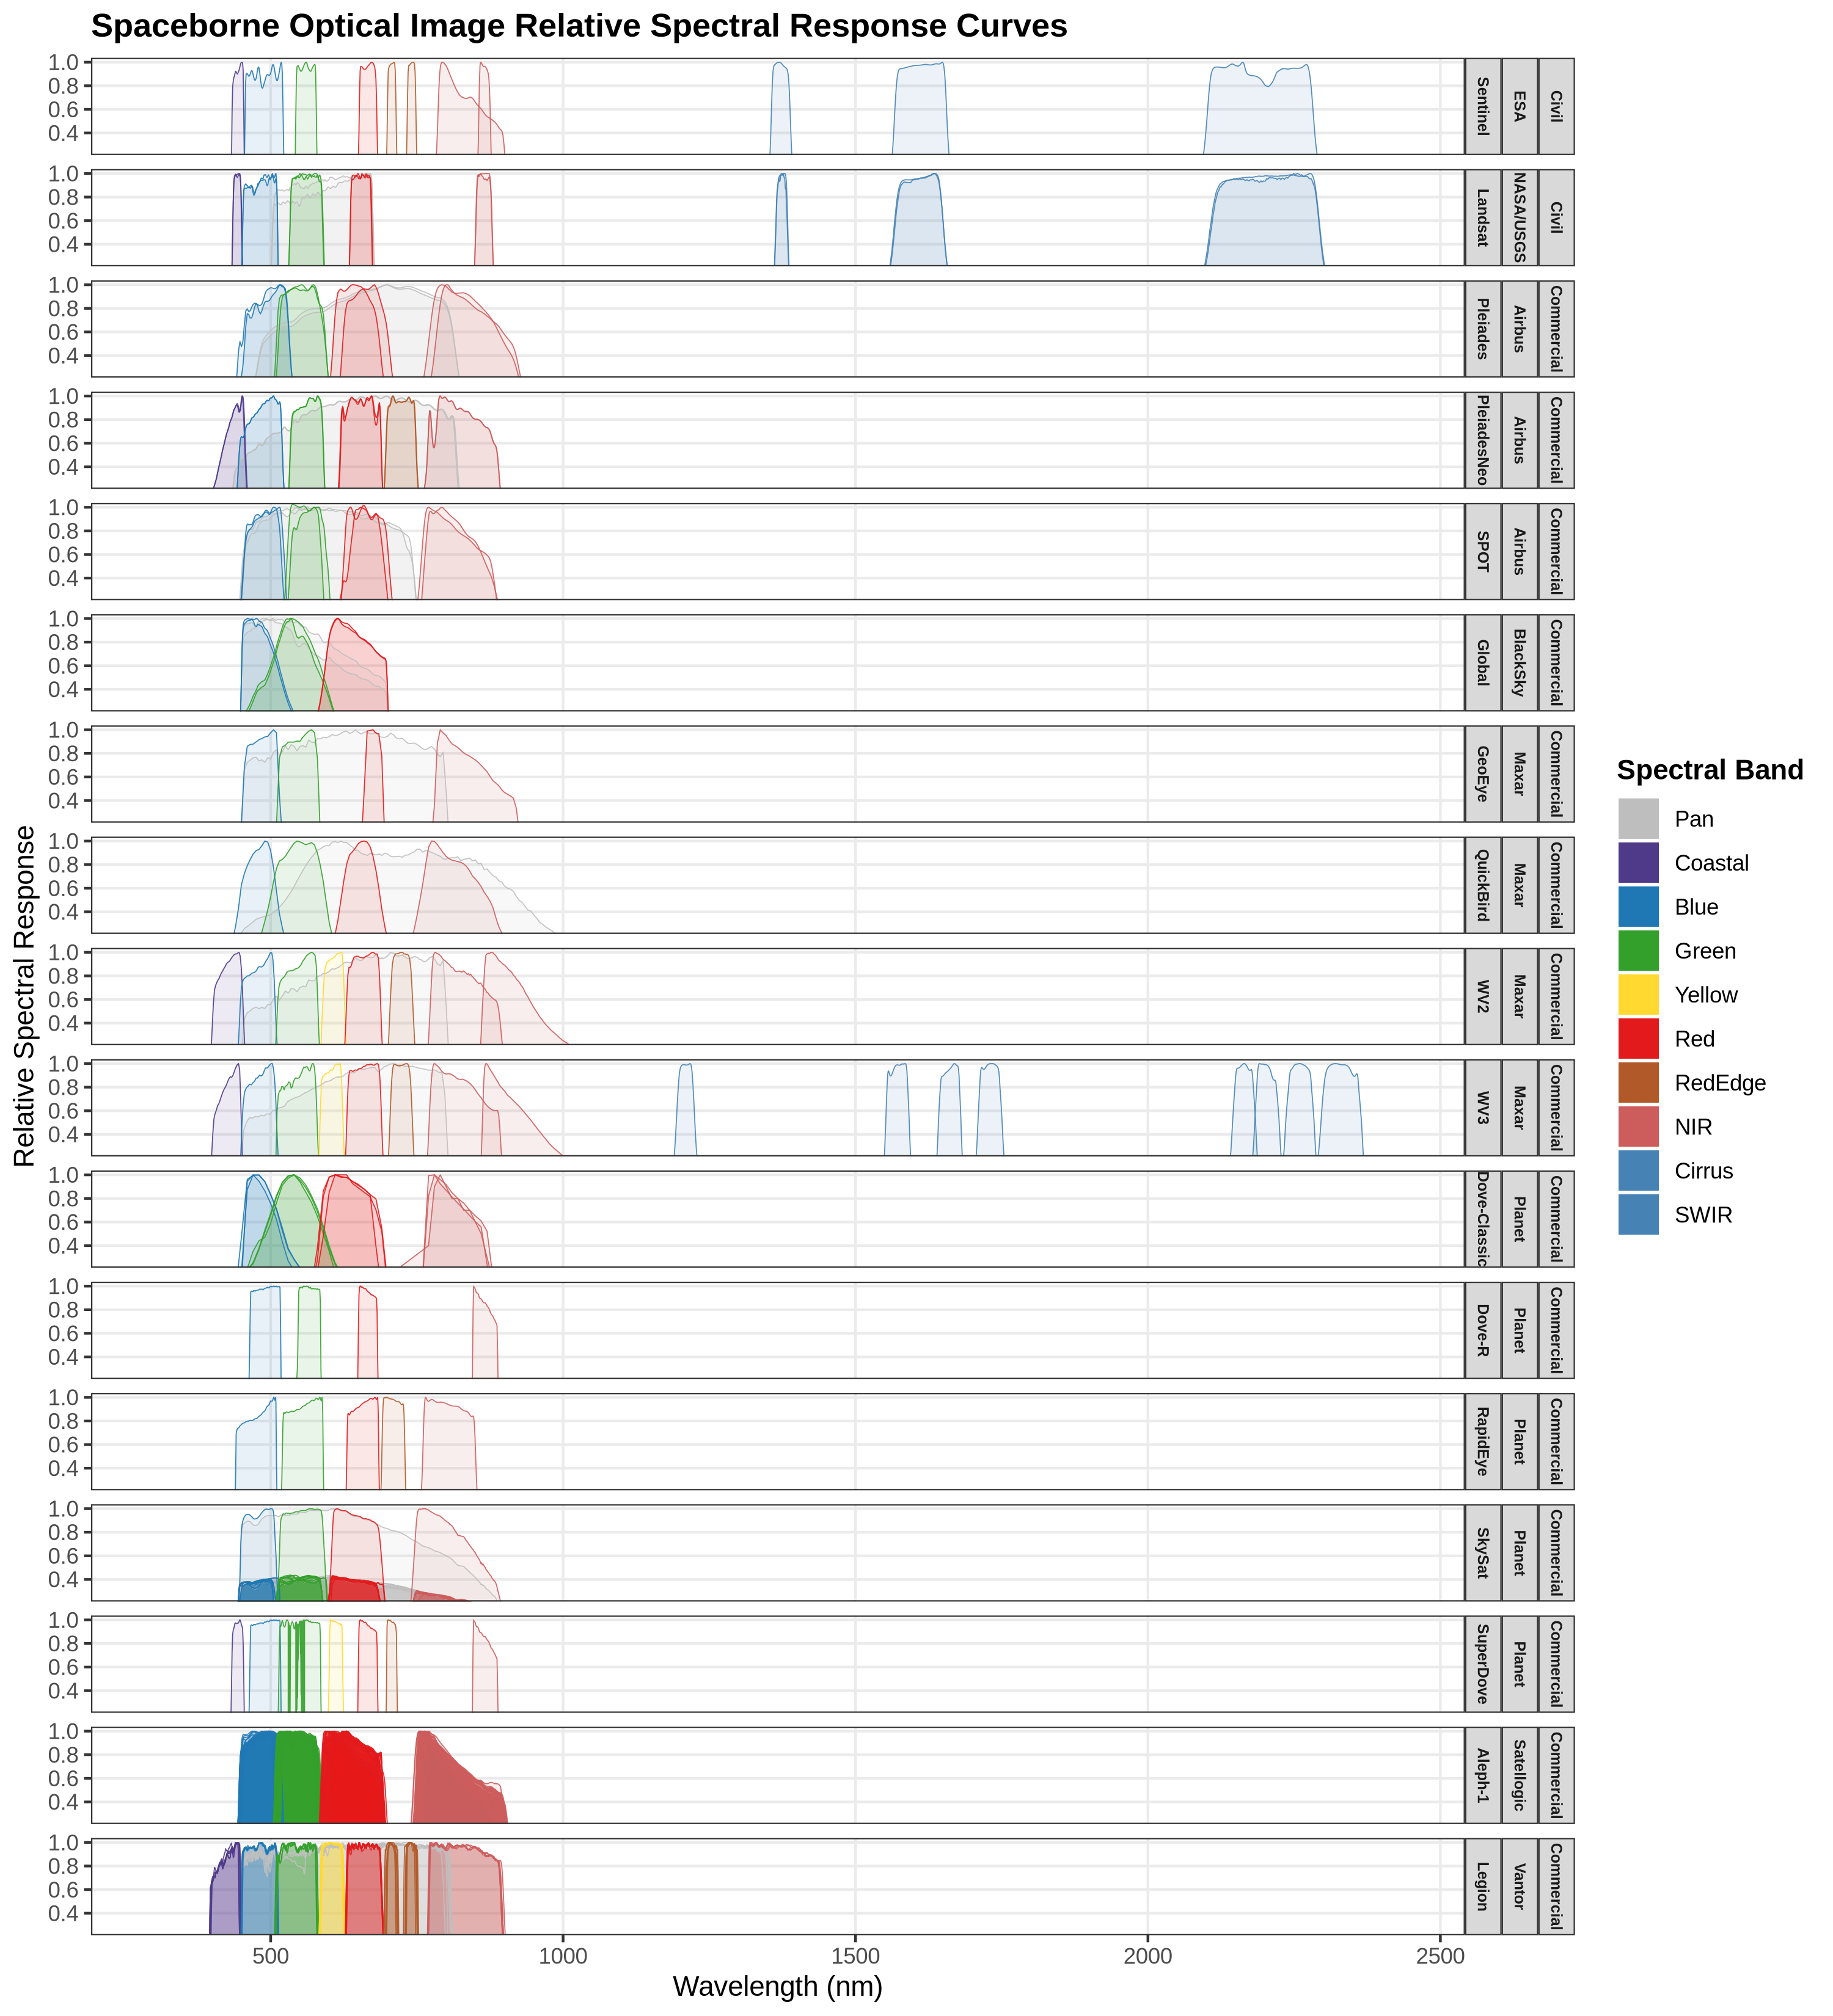

In [49]:
options(repr.plot.width = 10, repr.plot.height = 11, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(!(band %in% c('TIR1','TIR2'))))